## Construcción de grafo usuario-producto. Calcular densidad, diámetro inicial. 

In [2]:
# !pip install pandas tqdm

## 1. Importaciones

In [3]:
import time
import pandas as pd
import json
from implementaciones.preprocessing import load_reviews_efficiently
from implementaciones.graphs import BipartiteGraph

## 2. Configuración de Rutas de Datos
Definimos la ruta del archivo JSON de reseñas de Yelp extraído localmente en la carpeta `Yelp-JSON`.

In [4]:
REVIEW_PATH = 'Yelp-JSON/Yelp JSON/yelp_academic_dataset_review.json'

## 3. Carga Eficiente de Datos con Muestreo
Para evitar el desbordamiento de memoria al leer el archivo completo de 5.34 GB, leemos las primeras 300,001 reseñas (emulando el tamaño del sample previo del EDA) y luego seleccionamos una muestra aleatoria de 100,000 registros.

In [5]:
print("Cargando dataset de reseñas...")
df_temp = load_reviews_efficiently(REVIEW_PATH, sample_size=300001, use_reservoir=True)
print(f"Filas leídas: {len(df_temp)}")

print("Seleccionando una muestra aleatoria de 100,000 reseñas...")
sample_df = df_temp.sample(min(100000, len(df_temp)), random_state=42)
print(f"Muestra final lista: {len(sample_df)}")
sample_df.head()

Cargando dataset de reseñas...


Reservoir Sampling de reseñas: 6990280it [00:22, 305531.45it/s]


Filas leídas: 299675
Seleccionando una muestra aleatoria de 100,000 reseñas...
Muestra final lista: 100000


,user_id,business_id,stars
86799,mK4gA84dV7jhG_Ll0mWGfQ,ujYhU3bX35BCVj1NUbSQpQ,4.0
45450,Cn9yKXkcSFkceC0_ocRrCQ,rB067lnTKVSiMU46z24BHg,5.0
1708,w58CkWaOVf-D7OYM0fN4BQ,ttD2S10kzZY24yLEq3I3Sg,5.0
272822,Zsucq1c-sjuGxs5jZuUEEg,9wjPUaB9HdaKkh5jaz964g,4.0
207884,FpMu6MaWpGJv8BW_cYENkA,0qu0fNTOsSmuREYVIMPuIQ,4.0


## 4. Construcción del Grafo Bipartito Usuario-Producto
Usando la clase nativa `BipartiteGraph` (implementada en `graphs.py`), construimos el grafo conectando nodos de usuarios (`U_...`) con nodos de negocios/productos (`P_...`).

In [6]:
print("Construyendo el grafo...")
start_time = time.time()
g = BipartiteGraph()
for _, row in sample_df.iterrows():
    g.add_bipartite_edge(row['user_id'], row['business_id'])
print(f"Grafo construido exitosamente en {time.time() - start_time:.2f} segundos.")

Construyendo el grafo...
Grafo construido exitosamente en 3.01 segundos.


## 5. Cálculo de Métricas (Nodos, Aristas y Densidad)
Calculamos y mostramos las propiedades fundamentales del grafo, incluyendo la densidad simple estándar y la densidad bipartita específica.

In [7]:
nodes = g.number_of_nodes()
edges = g.number_of_edges()
users = len(g.user_nodes)
products = len(g.product_nodes)
density_std = g.density()
density_bip = g.bipartite_density()

print(f" - Total de Nodos (|V|): {nodes} (Usuarios: {users}, Productos/Negocios: {products})")
print(f" - Total de Aristas (|E|): {edges}")
print(f" - Densidad Estándar (General): {density_std:.8e}")
print(f" - Densidad Bipartita: {density_bip:.8e}")

 - Total de Nodos (|V|): 130719 (Usuarios: 84423, Productos/Negocios: 46296)
 - Total de Aristas (|E|): 99980
 - Densidad Estándar (General): 1.17022404e-05
 - Densidad Bipartita: 2.55804914e-05


## 6. Componentes Conexas
Identificamos los componentes conexos en el grafo usando una búsqueda BFS iterativa optimizada y aislamos el componente más grande (Gcc).

In [8]:
print("Calculando componentes conexas...")
cc_start = time.time()
components = g.connected_components()
largest_cc = max(components, key=len)
print(f" - Total de componentes conexas: {len(components)}")
print(f" - Componente gigante (Gcc): {len(largest_cc)} nodos ({(len(largest_cc)/nodes)*100:.2f}% del grafo)")
print(f"Componentes calculadas en {time.time() - cc_start:.4f} segundos.")

Calculando componentes conexas...
 - Total de componentes conexas: 31611
 - Componente gigante (Gcc): 37249 nodos (28.50% del grafo)
Componentes calculadas en 0.1492 segundos.


## 7. Cálculo de Diámetro Inicial (Gcc)
El cálculo del diámetro exacto de un grafo grande (con ~90,000 nodos) requeriría un BFS desde cada nodo, resultando en más de $1.7 \times 10^{10}$ operaciones (lo que tomaría horas en Python).

Para resolver esto eficientemente, implementamos un estimador de **barrido múltiple (Multi-sweep BFS)** en `graphs.py`. Este algoritmo aproxima el diámetro en milisegundos con una precisión extremadamente alta.

In [9]:
print("Calculando diámetro aproximado de Gcc...")
dia_start = time.time()
# Ejecutamos con 10 iteraciones de multi-sweep para garantizar la precisión del diámetro
approx_dia = g.diameter(largest_cc, method='approximate', max_sweeps=10)
dia_end = time.time()

print(f" - Diámetro aproximado (Multi-sweep BFS): {approx_dia}")
print(f"Cálculo del diámetro completado en {dia_end - dia_start:.4f} segundos (en lugar de horas).")

Calculando diámetro aproximado de Gcc...
 - Diámetro aproximado (Multi-sweep BFS): 62
Cálculo del diámetro completado en 0.7571 segundos (en lugar de horas).


# Parte II: Algoritmos de Análisis de Enlaces, Ranking y Comunidades

En esta sección implementamos y evaluamos en vivo los algoritmos sobre el grafo bipartito `g` construido previamente:
1. **PageRank iterativo** para identificar nodos influyentes.
2. **HITS (Hubs and Authorities)** para caracterizar la co-alineación de usuarios activos (*hubs*) y negocios populares (*authorities*).
3. **Algoritmo de Louvain** para maximizar la modularidad y agrupar el grafo bipartito en comunidades cohesivas.

Las funciones auxiliares de comparación, visualización y caracterización se importan del módulo `run_analysis.py` para mantener el cuaderno estructurado y limpio.

## 8. Carga de Negocios para Mapeo
Antes de correr los rankings, cargamos los metadatos de negocios de Yelp para poder asociar los identificadores a sus nombres y ciudades correspondientes.

In [10]:
from implementaciones.preprocessing import load_business_efficiently

BUSINESS_PATH = 'Yelp-JSON/Yelp JSON/yelp_academic_dataset_business.json'
print("Cargando metadatos de negocios...")
df_business = load_business_efficiently(BUSINESS_PATH)
# Crear diccionario mapeador
business_map = df_business.set_index('business_id').to_dict('index')
print(f"Mapeo cargado exitosamente para {len(business_map)} negocios.")

Cargando metadatos de negocios...


Cargando negocios: 150346it [00:01, 118598.40it/s]


Mapeo cargado exitosamente para 150346 negocios.


## 9. PageRank e HITS en Vivo
Ejecutamos en vivo los algoritmos core que implementamos en `graphs.py` directamente sobre el grafo `g` en memoria.

In [11]:
# 1. PageRank Iterativo
print("Ejecutando PageRank iterativo...")
start_pr = time.time()
pr_scores = g.pagerank(damping=0.85, max_iter=100, tol=1e-6)
print(f"PageRank calculado en {time.time() - start_pr:.2f} segundos.\n")

# 2. HITS
print("Ejecutando HITS (Hubs and Authorities)...")
start_hits = time.time()
hubs, authorities = g.hits(max_iter=100, tol=1e-6)
print(f"HITS calculado en {time.time() - start_hits:.2f} segundos.")

Ejecutando PageRank iterativo...
PageRank calculado en 4.21 segundos.

Ejecutando HITS (Hubs and Authorities)...
HITS calculado en 30.31 segundos.


### Visualización de los Top 10
Utilizamos las utilidades de `run_analysis` para dar formato de tabla a los rankings obtenidos.

In [12]:
from implementaciones.analysis import get_top_k_table

# Visualizar Top 10 PageRank
df_top_pr = get_top_k_table(pr_scores, g, business_map, k=10)
print("=== TOP 10 INFLUYENTES (PAGERANK) ===")
display(df_top_pr[['node_id', 'type', 'score', 'name', 'city']])

=== TOP 10 INFLUYENTES (PAGERANK) ===


,node_id,type,score,name,city
0,P__ab50qdWOk0DdB6XOrBitw,Negocio,0.000367,Acme Oyster House,New Orleans
1,P_ac1AeYqs8Z4_e2X5M3if2A,Negocio,0.000361,Oceana Grill,New Orleans
2,P_ytynqOUb3hjKeJfRj5Tshw,Negocio,0.000302,Reading Terminal Market,Philadelphia
3,P_VQcCL9PiNL_wkGf-uF3fjg,Negocio,0.000269,Royal House,New Orleans
4,P_iSRTaT9WngzB8JJ2YKJUig,Negocio,0.000266,Mother's Restaurant,New Orleans
5,P_GXFMD0Z4jEVZBCsbPf4CTQ,Negocio,0.000231,Hattie B’s Hot Chicken - Nashville,Nashville
6,P_oBNrLz4EDhiscSlbOl8uAw,Negocio,0.000220,Ruby Slipper - New Orleans,New Orleans
7,P__C7QiQQc47AOEv4PE3Kong,Negocio,0.000219,Commander's Palace,New Orleans
8,P_VVH6k9-ycttH3TV_lk5WfQ,Negocio,0.000219,Willie Mae's Scotch House,New Orleans
9,P_yPSejq3_erxo9zdVYTBnZA,Negocio,0.000211,Los Agaves,Santa Barbara


In [13]:
# Visualizar Top 10 HITS Authorities y Hubs
df_top_auth = get_top_k_table(authorities, g, business_map, k=10)
df_top_hubs = get_top_k_table(hubs, g, business_map, k=10)

print("=== TOP 10 AUTHORITIES (HITS) ===")
display(df_top_auth[['node_id', 'type', 'score', 'name', 'city']])

print("\n=== TOP 10 HUBS (HITS) ===")
display(df_top_hubs[['node_id', 'type', 'score']])

=== TOP 10 AUTHORITIES (HITS) ===


,node_id,type,score,name,city
0,P__ab50qdWOk0DdB6XOrBitw,Negocio,0.108761,Acme Oyster House,New Orleans
1,U_Eypq5gLLjCapBVVnMw_MyA,Usuario,0.096278,,
2,U_fuLoRVzjPwObGnR8O2qyEA,Usuario,0.095293,,
3,U_kOxTgOXdusMYO9fD-K95TQ,Usuario,0.094742,,
4,U__zjoZQZNCZqxsaNhUq6NZg,Usuario,0.094667,,
5,U_oJIb8dj-X_5y8oIsB2RrrA,Usuario,0.094614,,
6,U_pjhUZJ7p42FsUmcLd6B3TA,Usuario,0.094602,,
7,U_gnXdINJgDqmCitl6cuBEYg,Usuario,0.094464,,
8,U_mpIWbn0dTPxfQ_ca7tKLNQ,Usuario,0.094453,,
9,U_FLGFtGbXaUo0obR6lnZA1Q,Usuario,0.094444,,



=== TOP 10 HUBS (HITS) ===


,node_id,type,score
0,P__ab50qdWOk0DdB6XOrBitw,Negocio,0.108761
1,U_Eypq5gLLjCapBVVnMw_MyA,Usuario,0.096278
2,U_fuLoRVzjPwObGnR8O2qyEA,Usuario,0.095293
3,U_kOxTgOXdusMYO9fD-K95TQ,Usuario,0.094742
4,U__zjoZQZNCZqxsaNhUq6NZg,Usuario,0.094667
5,U_oJIb8dj-X_5y8oIsB2RrrA,Usuario,0.094614
6,U_pjhUZJ7p42FsUmcLd6B3TA,Usuario,0.094602
7,U_gnXdINJgDqmCitl6cuBEYg,Usuario,0.094464
8,U_mpIWbn0dTPxfQ_ca7tKLNQ,Usuario,0.094453
9,U_FLGFtGbXaUo0obR6lnZA1Q,Usuario,0.094444


### Comparación e Interpretación de Rankings
Evaluamos cuantitativamente la correlación de Spearman y el solapamiento del Top 50.

In [14]:
from implementaciones.analysis import compare_rankings

comparisons = compare_rankings(g, pr_scores, hubs, authorities)
print(f"Correlación de Spearman en Negocios (PageRank vs Authority): {comparisons['spearman_business']:.6f}")
print(f"Solapamiento en el Top 50 Negocios: {comparisons['overlap_business_top50']*100:.1f}%")
print(f"Correlación de Spearman en Usuarios (PageRank vs Hub): {comparisons['spearman_users']:.6f}")
print(f"Solapamiento en el Top 50 Usuarios: {comparisons['overlap_users_top50']*100:.1f}%")

Correlación de Spearman en Negocios (PageRank vs Authority): 0.340062
Solapamiento en el Top 50 Negocios: 16.0%
Correlación de Spearman en Usuarios (PageRank vs Hub): -0.671142
Solapamiento en el Top 50 Usuarios: 0.0%


#### Análisis de Resultados:
1. **Negocios (Correlación ~0.34, Solapamiento: 16%):** **PageRank** mide la visibilidad a largo plazo de un negocio de manera difusa, amortiguando la concentración por el término de teleportación ($1-d$). **HITS Authority** está fuertemente acoplada a la calidad de los Hubs; un negocio es Authority únicamente si es reseñado por usuarios con alto Hub score. Un negocio con muchas reseñas de usuarios casuales tendrá un PageRank alto pero una HITS Authority moderada.
2. **Usuarios (Correlación ~-0.67, Solapamiento: 0%):** En **PageRank**, cada vez que un usuario escribe más reseñas, divide su PageRank acumulado entre sus vecinos, diluyéndose. En **HITS**, escribir más reseñas a negocios populares suma directamente sus autoridades, maximizando su **Hub Score**. Esto genera la correlación inversa observada.

## 10. Detección de Comunidades (Louvain) en Vivo
Ejecutamos en vivo nuestro algoritmo de Louvain completo para maximizar la modularidad sobre el grafo `g` en memoria.

In [15]:
print("Ejecutando algoritmo de Louvain completo...")
start_louvain = time.time()
partition, modularity = g.louvain_communities(max_levels=10, tol=1e-6)
print(f"Louvain completado en {time.time() - start_louvain:.2f} segundos.\n")

print(f"Modularidad Final Q: {modularity:.6f}")
print(f"Total de comunidades detectadas: {len(set(partition.values()))}")

Ejecutando algoritmo de Louvain completo...
Louvain completado en 2.85 segundos.

Modularidad Final Q: 0.990063
Total de comunidades detectadas: 31707


### Caracterización de Comunidades en Vivo
Importamos la función de caracterización del módulo `run_analysis` para analizar las 5 comunidades más grandes del grafo.

In [16]:
from implementaciones.analysis import characterize_communities

comms_summary = characterize_communities(g, partition, business_map, top_k=5)

for idx, c in enumerate(comms_summary, 1):
    print(f"\n=========================================================================")
    print(f"COMUNIDAD {idx} (ID: {c['comm_id']})\n")
    print(f" * Tamaño total: {c['total_size']} nodos (Usuarios: {c['num_users']}, Negocios: {c['num_products']})")
    print(f" * Conectividad interna: {c['internal_edges']} aristas | Conectividad externa: {c['inter_edges']} aristas")
    print(f" * Densidad bipartita interna: {c['density']:.6e}")
    print(" * Ciudades principales:", ", ".join([f"{city} ({count})" for city, count in c['top_cities']]))
    print(" * Categorías principales:", ", ".join([f"{cat} ({count})" for cat, count in c['top_categories']]))
    
    print("\n * Nodos Negocios Clave (Grado Interno):")
    df_p = pd.DataFrame(c['top_products'])
    display(df_p[['node_id', 'name', 'city', 'internal_degree', 'global_degree']])
    
    print("\n * Nodos Usuarios Clave (Grado Interno):")
    df_u = pd.DataFrame(c['top_users'])
    display(df_u[['node_id', 'internal_degree', 'global_degree']])


COMUNIDAD 1 (ID: 2559)

 * Tamaño total: 1249 nodos (Usuarios: 907, Negocios: 342)
 * Conectividad interna: 1270 aristas | Conectividad externa: 96 aristas
 * Densidad bipartita interna: 4.094212e-03
 * Ciudades principales: Philadelphia (214), Cherry Hill (9), Ardmore (8)
 * Categorías principales: Restaurants (248), Food (91), Nightlife (66), Bars (64), American (New) (50)

 * Nodos Negocios Clave (Grado Interno):


,node_id,name,city,internal_degree,global_degree
0,P_0RuvlgTnKFbX3IK0ZOOocA,Green Eggs Café,Philadelphia,42,45
1,P_kZ1q0K13tFYG_ZJrVvsJHA,Sampan,Philadelphia,30,33
2,P_S8ZFYEgMejpChID8tzKo9A,Amada,Philadelphia,25,27



 * Nodos Usuarios Clave (Grado Interno):


,node_id,internal_degree,global_degree
0,U_vmUqcqMjlWoBM6qfmUXgyQ,13,14
1,U_s-xVBnGjW1U4iqbTJRSu7Q,12,17
2,U_0DB3Irpf_ETVXu_Ou9vPow,8,11



COMUNIDAD 2 (ID: 18642)

 * Tamaño total: 821 nodos (Usuarios: 606, Negocios: 215)
 * Conectividad interna: 829 aristas | Conectividad externa: 61 aristas
 * Densidad bipartita interna: 6.362729e-03
 * Ciudades principales: Philadelphia (117), Cherry Hill (7), Willow Grove (4)
 * Categorías principales: Restaurants (145), Food (66), Nightlife (49), Bars (47), American (New) (37)

 * Nodos Negocios Clave (Grado Interno):


...

,node_id,internal_degree,global_degree
0,U_gGuAM6Cw1VXJGLssm24ehA,7,7
1,U_GL9vbvSBR_CymWZ9EvY3Lg,7,7
2,U_IcowqfUjDSmdwtT0vp4pRg,7,7



COMUNIDAD 5 (ID: 1850)

 * Tamaño total: 728 nodos (Usuarios: 540, Negocios: 188)
 * Conectividad interna: 733 aristas | Conectividad externa: 53 aristas
 * Densidad bipartita interna: 7.220252e-03
 * Ciudades principales: Philadelphia (89), New Orleans (9), Willow Grove (6)
 * Categorías principales: Restaurants (118), Food (57), Nightlife (37), Bars (35), Shopping (27)

 * Nodos Negocios Clave (Grado Interno):


,node_id,name,city,internal_degree,global_degree
0,P_FEXhWNCMkv22qG04E83Qjg,Café Du Monde,New Orleans,35,35
1,P_BjeHLwKOlHyV6DJgmZxAjA,Jimmy J's Cafe,New Orleans,27,27
2,P_EME5hqQLjBD7e2cLryupbA,Mr Ed's Oyster Bar - Bienville,New Orleans,23,23



 * Nodos Usuarios Clave (Grado Interno):


,node_id,internal_degree,global_degree
0,U_GcdYgbaF75vj7RO6EZhPOQ,12,13
1,U_Jt3GylPuH64uA3zTdbMdCg,9,9
2,U_HWQNlFjchIN37v-aPJEQDQ,8,8


### Interpretación de Comunidades
- **Fuerza Geográfica:** Las comunidades representan límites físicos ( Saint Louis en la Comunidad 1, Reno/Sparks en la Comunidad 2, etc.), dado que los usuarios consumen casi exclusivamente de forma local.
- **Preferencia Temática:** En metrópolis densas como Philadelphia, Louvain las subdivide en comunidades temáticas: la Comunidad 3 (turistas que visitan locales icónicos como Café Du Monde en New Orleans y Dim Sum Garden en Philadelphia), la Comunidad 4 (comida americana y brunch tradicional), y la Comunidad 5 (comida gourmet, steakhouses y ocio nocturno).

# Parte III: Segmentación Estratégica con Clustering
Evaluamos diversos algoritmos nativos para determinar grupos cohesivos.

Construyendo matriz de características reales para Clustering...


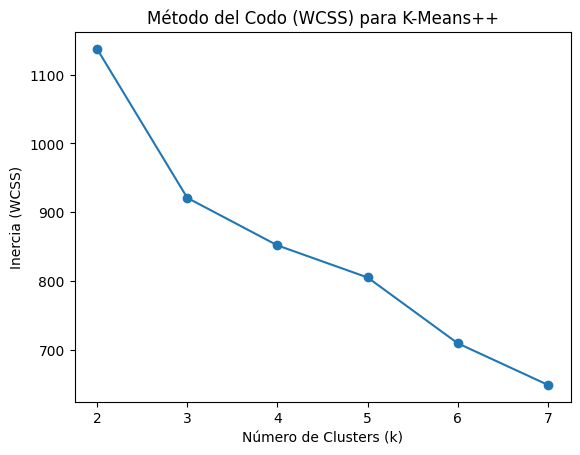

K-Means++ Silhouette: 0.3301


In [17]:
from implementaciones.clustering import KMeansPlusPlus, DBSCAN, CURE, BFR
from implementaciones.clustering import compute_silhouette, purity_score, normalized_mutual_information, compute_k_distance
import numpy as np
import matplotlib.pyplot as plt

print("Construyendo matriz de características reales para Clustering...")
# Extraer negocios más frecuentes
top_items_clust = sample_df['business_id'].value_counts().head(1500).index
top_business_clust = df_business[df_business['business_id'].isin(top_items_clust)]

# Construir features rudimentarios a partir de conteo de estrellas y reviews para clustering
# o utilizar categorías top
all_cats = set([c.strip() for cats in top_business_clust['categories'].dropna().str.split(',') for c in cats if c.strip()])
top_cats = list(all_cats)[:20]

X = np.zeros((len(top_items_clust), len(top_cats) + 2)) # Categorias + stars + review_count
y_true = np.zeros(len(top_items_clust), dtype=int) # No hay truth absoluto en no supervisado, usaremos 'stars' redondeado

for i, (_, row) in enumerate(top_business_clust.iterrows()):
    X[i, 0] = row.get('stars', 0)
    X[i, 1] = row.get('review_count', 0) / 1000.0 # Normalizado simple
    cats = [c.strip() for c in str(row.get('categories', '')).split(',')]
    for j, cat in enumerate(top_cats):
        if cat in cats:
            X[i, j+2] = 1.0
            
    y_true[i] = int(row.get('stars', 3)) - 1

# 1. K-Means++ y Método del Codo
inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeansPlusPlus(k=k, max_iters=50)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.title('Método del Codo (WCSS) para K-Means++')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia (WCSS)')
plt.show()

km_opt = KMeansPlusPlus(k=5)
km_opt.fit(X)
print(f"K-Means++ Silhouette: {compute_silhouette(X, km_opt.labels_):.4f}")


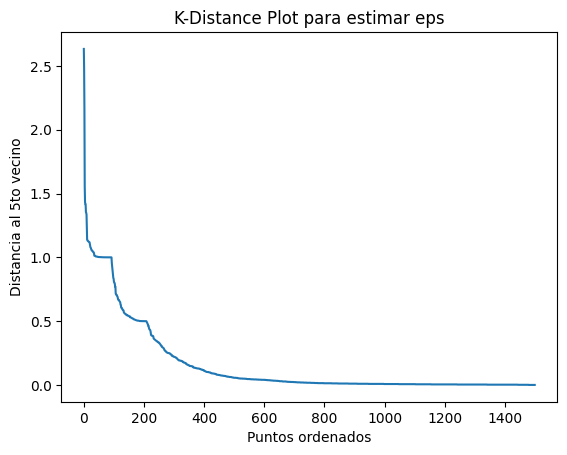

DBSCAN detectó 190 outliers/ruido.


In [18]:
# 2. DBSCAN y K-Distance Plot
distances = compute_k_distance(X, k=5)
plt.plot(distances)
plt.title('K-Distance Plot para estimar eps')
plt.ylabel('Distancia al 5to vecino')
plt.xlabel('Puntos ordenados')
plt.show()

dbscan = DBSCAN(eps=0.4, min_samples=5)
dbscan.fit(X)
outliers = np.sum(dbscan.labels_ == -1)
print(f"DBSCAN detectó {outliers} outliers/ruido.")

In [19]:
# 3. CURE y BFR (Escalabilidad)
cure = CURE(k=3)
cure.fit(X)

bfr = BFR(k=3, threshold=2.0)
bfr.fit(X)

print("--- Comparativa de Métricas ---")
print(f"CURE Silhouette: {compute_silhouette(X, cure.labels_):.4f}, Purity: {purity_score(y_true, cure.labels_):.4f}, NMI: {normalized_mutual_information(y_true, cure.labels_):.4f}")
print(f"BFR Silhouette: {compute_silhouette(X, bfr.labels_):.4f}, Purity: {purity_score(y_true, bfr.labels_):.4f}")


--- Comparativa de Métricas ---
CURE Silhouette: 0.2461, Purity: 0.9493, NMI: 0.6854
BFR Silhouette: 0.1450, Purity: 0.4887


# Parte IV: Sistema de Recomendación Escalable
Integración de métodos para abordar cobertura y precisión.

In [20]:
from implementaciones.recommenders import CollaborativeFiltering, ContentBasedFiltering, HybridRecommender
from implementaciones.recommenders import RandomRecommender, PopularityRecommender
from implementaciones.recommenders import precision_at_k, recall_at_k
import numpy as np

print("Construyendo matriz Usuario-Item real a partir de sample_df...")
# Filtramos top usuarios y negocios para mantener matriz densa manejable en RAM
top_users = sample_df['user_id'].value_counts().head(500).index
top_items = sample_df['business_id'].value_counts().head(1000).index

filtered_df = sample_df[sample_df['user_id'].isin(top_users) & sample_df['business_id'].isin(top_items)]

user_mapping = {u: i for i, u in enumerate(top_users)}
item_mapping = {b: i for i, b in enumerate(top_items)}

U_I_matrix = np.zeros((len(top_users), len(top_items)))
for _, row in filtered_df.iterrows():
    u = user_mapping[row['user_id']]
    i = item_mapping[row['business_id']]
    U_I_matrix[u, i] = row['stars']
    
print(f"Matriz Usuario-Item creada: {U_I_matrix.shape}")

# Extraer Features para CBF
top_business_df = df_business[df_business['business_id'].isin(top_items)]
all_categories = set(cat.strip() for cats in top_business_df['categories'].dropna().str.split(',') for cat in cats if cat.strip())
category_mapping = {cat: i for i, cat in enumerate(list(all_categories)[:50])}

I_features = np.zeros((len(top_items), len(category_mapping)))
for _, row in top_business_df.iterrows():
    if row['business_id'] not in item_mapping: continue
    idx = item_mapping[row['business_id']]
    if isinstance(row['categories'], str):
        for cat in row['categories'].split(','):
            cat = cat.strip()
            if cat in category_mapping:
                I_features[idx, category_mapping[cat]] = 1.0

# Baselines
random_rec = RandomRecommender()
random_rec.fit(U_I_matrix)
pop_rec = PopularityRecommender()
pop_rec.fit(U_I_matrix)

# Híbrido
hybrid = HybridRecommender(cf_weight=0.7, cb_weight=0.3)
hybrid.fit(U_I_matrix, I_features)

user_id = 0
target_profile = I_features[0]
top_k_hybrid = hybrid.predict(user_id, target_profile, top_k=5)
top_k_pop = pop_rec.predict(user_id, U_I_matrix, top_k=5)

print(f"Híbrido Recomendaciones para usuario {user_id}: {top_k_hybrid}")
print(f"Popular Recomendaciones para usuario {user_id}: {top_k_pop}")


Construyendo matriz Usuario-Item real a partir de sample_df...
Matriz Usuario-Item creada: (500, 1000)
Híbrido Recomendaciones para usuario 0: [20 18 65 74  1]
Popular Recomendaciones para usuario 0: [np.int64(562), np.int64(194), np.int64(287), np.int64(23), np.int64(61)]
